In [ ]:
import json
import numpy as np
import pandas as pd
import os
from tqdm.auto import tqdm
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
type_of_questions = {
    "commonsensqa": "Common Sense",
    "strategyqa": "Common Sense",
    "coin_flip": "Symbolic",
    "last_letters": "Symbolic",
    # "object_tracking": "Other",
    # "bigbench_date": "Other",
    # all others, Arithmetic
    "addsub": "Arithmetic",
    "gsm8k": "Arithmetic",
    "singleeq": "Arithmetic",
    "aqua": "Arithmetic",
    "svamp": "Arithmetic",
    "multiarith": "Arithmetic",
}

In [ ]:
benchmarks = os.listdir("probabilities/system1")

In [ ]:
benchmarks

['commonsensqa',
 '.ipynb_checkpoints',
 'last_letters',
 'aqua',
 'svamp',
 'gsm8k',
 'multiarith',
 'strategyqa',
 'coin_flip',
 'addsub',
 'singleeq']

In [ ]:
del benchmarks[1]

In [ ]:
benchmarks

['commonsensqa',
 'last_letters',
 'aqua',
 'svamp',
 'gsm8k',
 'multiarith',
 'strategyqa',
 'coin_flip',
 'addsub',
 'singleeq']

In [ ]:
datasets = dict()
for benchmark in benchmarks:
    print(benchmark)
    with open(os.path.join("probabilities/system1", benchmark, "merged.json")) as f:
        sys1_data = json.load(f)

    with open(os.path.join("probabilities/system2", benchmark, "merged.json")) as f:
        sys2_data = json.load(f)

    assert len(sys1_data) == len(sys2_data)
    datasets[benchmark] = {"sys1": sys1_data, "sys2": sys2_data}

commonsensqa
last_letters
aqua
svamp
gsm8k
multiarith
strategyqa
coin_flip
addsub
singleeq


In [ ]:
def filter_end_of_sentences(tokens_probs):
    filtered_tokens_probs = [
        (token, prob) for token, prob in tokens_probs if token != "<|eot_id|>"
    ]
    return filtered_tokens_probs

In [ ]:
def get_sentence_prob_multi(token_probs):
    probs = [prob for token, prob in token_probs]
    log_probs = np.log(probs)
    return np.sum(log_probs) / len(log_probs)


def get_sentence_prob_mean(token_probs):
    probs = [prob for token, prob in token_probs]
    return np.mean(probs)

In [ ]:
datasets_lists = []
system_types = []
ability_lists = []
data_probs_sum_log = []
data_probs_mean_token_prob = []

for dataset in datasets.keys():
    sys1_data = datasets[dataset]["sys1"]
    sys2_data = datasets[dataset]["sys2"]

    for sys1_datapoint, sys2_datapoint in zip(sys1_data, sys2_data):
        sys1_tokens_probs = filter_end_of_sentences(sys1_datapoint)
        sys2_tokens_probs = filter_end_of_sentences(sys2_datapoint)

        data_probs_sum_log.append(get_sentence_prob_multi(sys1_tokens_probs))
        data_probs_sum_log.append(get_sentence_prob_multi(sys2_tokens_probs))

        data_probs_mean_token_prob.append(get_sentence_prob_mean(sys1_tokens_probs))
        data_probs_mean_token_prob.append(get_sentence_prob_mean(sys2_tokens_probs))

        system_types.append("sys1")
        system_types.append("sys2")

        datasets_lists.append(dataset)
        datasets_lists.append(dataset)

        ability_lists.append(type_of_questions[dataset])
        ability_lists.append(type_of_questions[dataset])


df = pd.DataFrame(
    {
        "dataset": datasets_lists,
        "system": system_types,
        "sum_log_probs": data_probs_sum_log,
        "mean_token_prob": data_probs_mean_token_prob,
        "ability": ability_lists,
    }
)

In [ ]:
from scipy.stats import ttest_rel

<ipython-input-20-2905e3270cd6>:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:skyblue'` for the same effect.

  sns.violinplot(
<ipython-input-20-2905e3270cd6>:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")


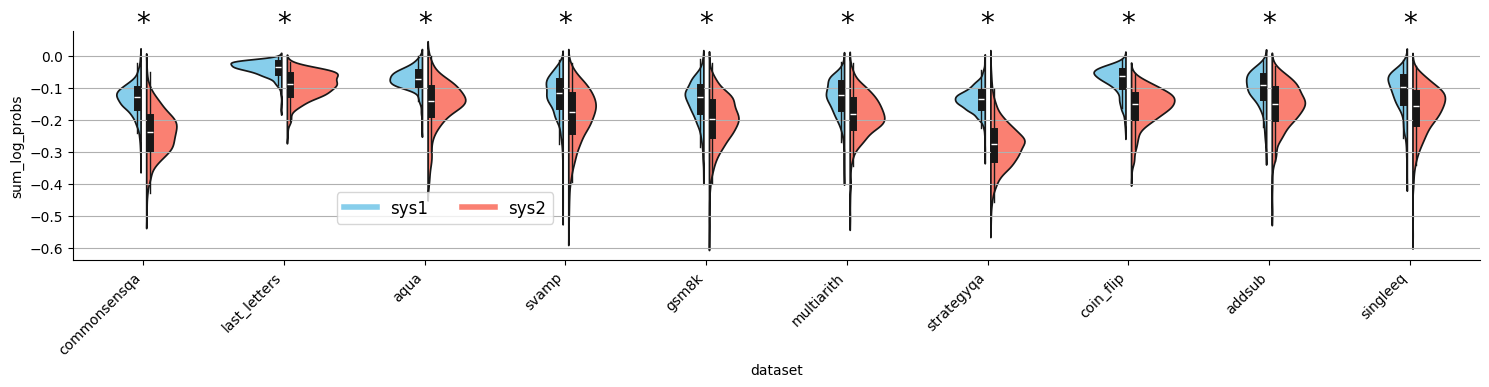

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 4))
sns.violinplot(
    x="dataset",
    y="sum_log_probs",
    hue="system",
    data=df,
    inner="box",
    split=True,
    gap=0.1,
    # common_norm=True,
    ax=ax,
    inner_kws=dict(
        box_width=5,
        whis_width=1,
    ),
    color="skyblue",
    # palette=[".4", ".7"],
)
colors = ["skyblue", "salmon"]

# put the xtick labels with a rotation of 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")
from matplotlib.collections import PolyCollection
from matplotlib.colors import to_rgb

for ind, violin in enumerate(ax.findobj(PolyCollection)):
    if ind % 2 != 0:
        rgb = to_rgb(colors[1])
    else:
        rgb = to_rgb(colors[0])
    violin.set_facecolor(rgb)

handles, labels = ax.get_legend_handles_labels()
# handles are salmon and skyblue
handles = [
    plt.Line2D([0], [0], color=colors[0], lw=4),
    plt.Line2D([0], [0], color=colors[1], lw=4),
]
ax.grid(axis="y")
ax.get_legend().remove()
sns.despine()

# on top of each of the xticks, check the difference between two systems using ttest_rel and if significant (< 0.05), put a star on top
for i, dataset in enumerate(df["dataset"].unique()):
    sys1_data = df[(df["dataset"] == dataset) & (df["system"] == "sys1")][
        "sum_log_probs"
    ]
    sys2_data = df[(df["dataset"] == dataset) & (df["system"] == "sys2")][
        "sum_log_probs"
    ]
    t, p = ttest_rel(sys1_data, sys2_data)
    if p < 0.05:
        ax.text(i, 0.1, "*", fontsize=20, ha="center", va="center", color="black")

fig.legend(
    handles,
    labels,
    bbox_to_anchor=(0.3, 0.4),
    loc="lower center",
    ncol=2,
    fontsize="large",
)

# save the figure
plt.tight_layout()
plt.savefig("sum_log_probs_violinplot.png", dpi=900, bbox_inches="tight")

In [ ]:
df['system'] = df['system'].replace({'sys1': 'System 1', 'sys2': 'System 2'})

T-test results for Common Sense: t(3510) = 106.860, p = 0.000
T-test results for Symbolic: t(999) = 42.537, p = 0.000
T-test results for Arithmetic: t(4075) = 54.539, p = 0.000


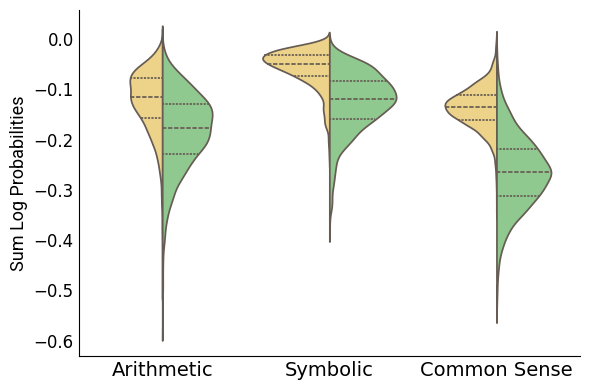

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

font_path = "/content/Roboto-Regular.ttf"
roboto_font_big = fm.FontProperties(fname=font_path, size=13)
roboto_font_med = fm.FontProperties(fname=font_path, size=13)
roboto_font_small = fm.FontProperties(fname=font_path, size=10)

# Define color palette and hue order
hue_order = ["System 1", "System 2"]
palette = {"System 1": "#fdda7a", "System 2": "#86d387"}

# Create figure and axes
fig, ax = plt.subplots(figsize=(6, 4))
order =["Arithmetic","Symbolic","Common Sense"]
# Violin plot
sns.violinplot(
    x="ability",
    y="sum_log_probs",
    hue="system",
    data=df,
    inner="quart",
    split=True,
    palette=palette,
    hue_order=hue_order,
    edgecolor="#665c53",
    order=order,
    ax=ax,
)

# Set titles and labels
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Sum Log Probabilities", fontproperties=roboto_font_big)

# Customize ticks
ax.tick_params(axis="y", labelsize=12, length=0)
ax.tick_params(axis="x", labelsize=14, length=0)

# Remove grid lines from spines
sns.despine()

# Perform t-tests and annotate significance
for i, ability in enumerate(df["ability"].unique()):
    sys1_data = df[(df["ability"] == ability) & (df["system"] == "System 1")]["sum_log_probs"]
    sys2_data = df[(df["ability"] == ability) & (df["system"] == "System 2")]["sum_log_probs"]

    t, p = ttest_rel(sys1_data, sys2_data)
    print(f"T-test results for {ability}: t({len(sys1_data)-1}) = {t:.3f}, p = {p:.3f}")

    # Add star if p < 0.05
    # if p < 0.05:
    #     ax.text(i, max(sys1_data.max(), sys2_data.max()) + 0.1, "*", ha="center", fontsize=16)

# Customize legend
# ax.legend(
#     title="",
#     loc="best",
#     frameon=False,
#     fontsize=12
# )
ax.get_legend().set_visible(False)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig("sum_log_probs_violinplot.png", dpi=900, bbox_inches="tight")
plt.show()
